In [13]:
conda list

WARNING conda.gateways.disk.delete:unlink_or_rename_to_trash(139): Could not remove or rename /opt/conda/conda-meta/jedi-0.18.0-py38h578d9bd_2.json.  Please remove this file manually (you may need to reboot to free file handles)
WARNING conda.gateways.disk.delete:unlink_or_rename_to_trash(139): Could not remove or rename /opt/conda/conda-meta/numpy-1.20.2-py38h9894fe3_0.json.  Please remove this file manually (you may need to reboot to free file handles)
WARNING conda.gateways.disk.delete:unlink_or_rename_to_trash(139): Could not remove or rename /opt/conda/conda-meta/parso-0.8.2-pyhd8ed1ab_0.json.  Please remove this file manually (you may need to reboot to free file handles)
# packages in environment at /opt/conda:
#
# Name                    Version                   Build  Channel
_libgcc_mutex             0.1                 conda_forge    conda-forge
_openmp_mutex             4.5                       1_gnu    conda-forge
abseil-cpp                20210324.0           h9c3ff4c_0 

## Tutorial from https://www.tensorflow.org/tutorials/keras/classification

In [1]:
%load_ext tensorboard

In [2]:
import tensorflow as tf
import datetime, os

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.3.0


In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


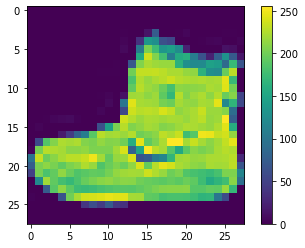

In [5]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()


In [6]:
train_images = train_images / 255.0
test_images = test_images / 255.0

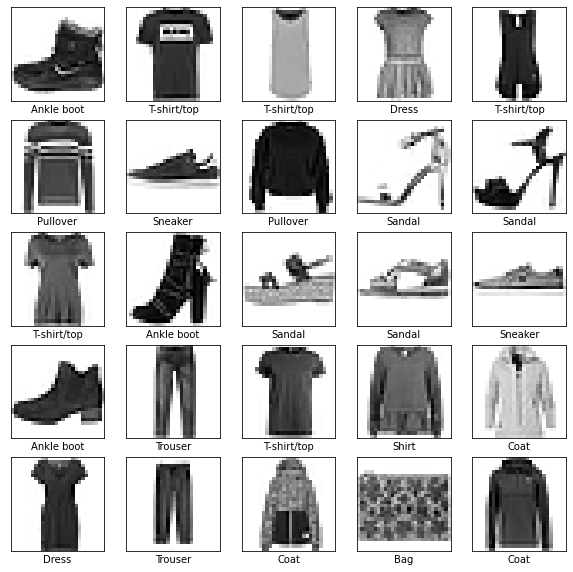

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

In [9]:
# Profile from batches 10 to 15
log_dir = "/pbs/home/b/barcelin/sps_link/data/log_test/"
tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
                                             profile_batch='10, 15')

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [11]:
model.fit(train_images, train_labels, epochs=100,callbacks=[tb_callback])

Epoch 1/100
   1/1875 [..............................] - ETA: 0s - loss: 2.4951 - accuracy: 0.0000e+00WARNING:tensorflow:From /opt/conda/lib/python3.8/site-packages/tensorflow/python/ops/summary_ops_v2.py:1277: stop (from tensorflow.python.eager.profiler) is deprecated and will be removed after 2020-07-01.
Instructions for updating:
use `tf.profiler.experimental.stop` instead.
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4949 - accuracy: 0.8254
Epoch 2/100
1875/1875 [==============================] - 3s 1ms/step - loss: 0.3744 - accuracy: 0.8644
Epoch 3/100
1875/1875 [==============================] - 3s 1ms/step - loss: 0.3381 - accuracy: 0.8767
Epoch 4/100
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3128 - accuracy: 0.8853
Epoch 5/100
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2933 - accuracy: 0.8934
Epoch 6/100
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2802 - accuracy: 0.8963
Epoch 7/100
18

KeyboardInterrupt: 

In [12]:
%tensorboard --logdir logs

In [10]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

10000/10000 - 0s - loss: 0.3351 - accuracy: 0.8855

Test accuracy: 0.8855


In [13]:
probability_model = tf.keras.Sequential([model, 
                                         tf.keras.layers.Softmax()])

In [14]:
predictions = probability_model.predict(test_images)

In [16]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

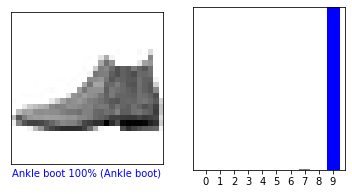

In [17]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()


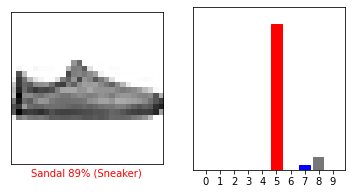

In [18]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

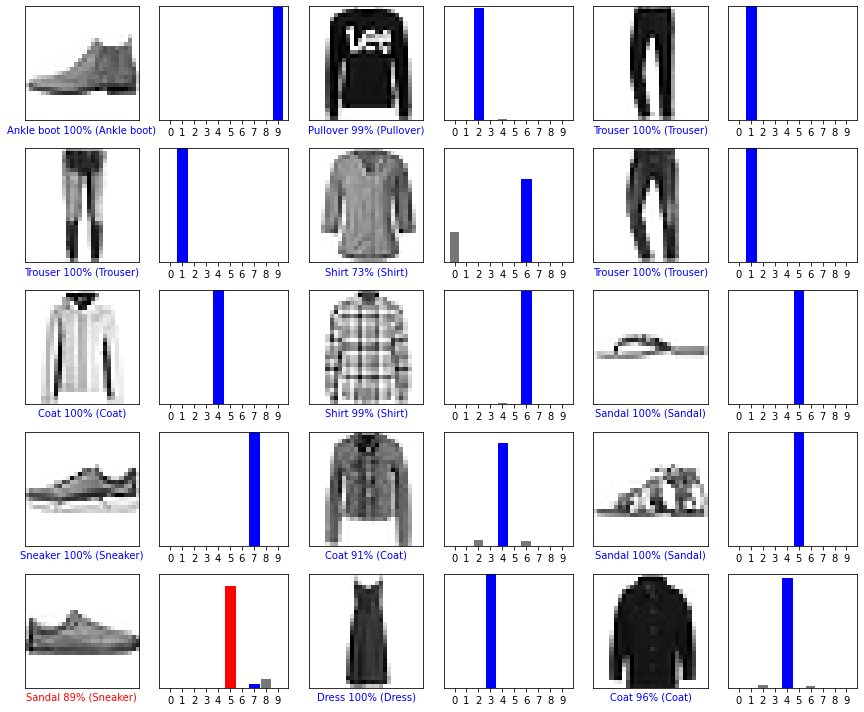

In [19]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()
